<a href="https://colab.research.google.com/github/DastanJin/ZSU/blob/main/fml_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamentals of Machine Learning - Exercise 9
Goal of this excercise is to complete the hands-on experience of the classification task.

## Household Prices Dataset
https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data

* ... I bet that you already know the data pretty well 😅

![meme03](https://github.com/rasvob/VSB-FEI-Fundamentals-of-Machine-Learning-Exercises/blob/master/images/fml_09_meme_03.jpg?raw=true)

**Important attributes description:**
* SalePrice: The property's sale price in dollars. This is the target variable that you're trying to predict.
* MSSubClass: The building class
* BldgType: Type of dwelling
* HouseStyle: Style of dwelling
* OverallQual: Overall material and finish quality
* OverallCond: Overall condition rating
* YearBuilt: Original construction date
* Heating: Type of heating
* CentralAir: Central air conditioning
* GrLivArea: Above grade (ground) living area square feet
* BedroomAbvGr: Number of bedrooms above basement level)



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, auc
from sklearn.preprocessing import OrdinalEncoder

# 🎯 Our goal is to predict if the house will be sold for more than 250k USD or not
* We will use categorized price as a **Target** variable

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/rasvob/VSB-FEI-Fundamentals-of-Machine-Learning-Exercises/master/datasets/zsu_cv1_data.csv', sep=',')
df = df.loc[:, ['SalePrice','MSSubClass','BldgType','HouseStyle','OverallQual','OverallCond','YearBuilt','Heating','CentralAir','GrLivArea','BedroomAbvGr']]
df.loc[:, ['Target']] = (df.SalePrice > 250000).astype(int)
df = df.drop(['SalePrice'], axis=1)

In [3]:
df.head()

,MSSubClass,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,Heating,CentralAir,GrLivArea,BedroomAbvGr,Target
0,60,1Fam,2Story,7,5,2003,GasA,Y,1710,3,0
1,20,1Fam,1Story,6,8,1976,GasA,Y,1262,3,0
2,60,1Fam,2Story,7,5,2001,GasA,Y,1786,3,0
3,70,1Fam,2Story,7,5,1915,GasA,Y,1717,3,0
4,60,1Fam,2Story,8,5,2000,GasA,Y,2198,4,0


# Take a look at the features
* We will need it to answer the questions

In [4]:
df.describe()

,MSSubClass,OverallQual,OverallCond,YearBuilt,GrLivArea,BedroomAbvGr,Target
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,6.099315,5.575342,1971.267808,1515.463699,2.866438,0.148630
std,42.300571,1.382997,1.112799,30.202904,525.480383,0.815778,0.355845
min,20.000000,1.000000,1.000000,1872.000000,334.000000,0.000000,0.000000
25%,20.000000,5.000000,5.000000,1954.000000,1129.500000,2.000000,0.000000
50%,50.000000,6.000000,5.000000,1973.000000,1464.000000,3.000000,0.000000
75%,70.000000,7.000000,6.000000,2000.000000,1776.750000,3.000000,0.000000
max,190.000000,10.000000,9.000000,2010.000000,5642.000000,8.000000,1.000000


## Categorial features EDA

In [5]:
df.describe(exclude=np.number)

,BldgType,HouseStyle,Heating,CentralAir
count,1460,1460,1460,1460
unique,5,8,6,2
top,1Fam,1Story,GasA,Y
freq,1220,726,1428,1365


### BldgType

In [6]:
df.BldgType.value_counts()

,count
BldgType,
1Fam,1220
TwnhsE,114
Duplex,52
Twnhs,43
2fmCon,31


### HouseStyle

In [7]:
df.HouseStyle.value_counts()

,count
HouseStyle,
1Story,726
2Story,445
1.5Fin,154
SLvl,65
SFoyer,37
1.5Unf,14
2.5Unf,11
2.5Fin,8


### Heating

In [8]:
df.Heating.value_counts()

,count
Heating,
GasA,1428
GasW,18
Grav,7
Wall,4
OthW,2
Floor,1


## Missing values

In [9]:
df.isna().sum()

,0
MSSubClass,0
BldgType,0
HouseStyle,0
OverallQual,0
OverallCond,0
YearBuilt,0
Heating,0
CentralAir,0
GrLivArea,0
BedroomAbvGr,0


## Labels distribution

In [10]:
df.Target.value_counts()

,count
Target,
0,1243
1,217


# ✅ Task (2p)
Complete the following tasks:

1. 📈 Describe what operations you are performing for each of the features
    * Mainly focus on categorical features
      
2. 📌 Answer the following questions:
    * **How many values are missing?**
    * **How many instances do you have in each of the classes?**
    * 🔎 **Which metric score do you propose for the classification model performance evaluation?**
        * 💡 This depends on your previous answer
          
3. ⚡Finish your preprocessing pipeline and split the data into the Input and Output part (i.e. `X` and `y` variables)

4. 🌳 Start with the **Decision Tree**
    * Use 5-fold cross validation
    * 🔎 Will you use *standard* cross validation or *stratified* cross validation?
    * Compute mean of the obtained score values
      
5. 🚀 Select one other algorithm from https://scikit-learn.org/stable/supervised_learning.html
    * Repeat the 5-fold CV
      
6. 📒 **Write down which default model is better**

7. 📊 Experiment with hyper-parameters
    * Select at least one important parameter for the model
    * Set the parameter value range
        * You can use random values, interval of values, ...
    * Do the 5-fold CV
        * Compute mean of the obtained score values
    * Document the experiment results using tables and/or plots
    * Describe the results in a Markdown cell

8. 📒 **Write down which model (default or tuned) is the best and why**

* **Document everything you do in a Markdown cells**
    * ❌ Results interpretation figured in real-time during task check is not allowed! ❌

![meme01](https://github.com/rasvob/VSB-FEI-Fundamentals-of-Machine-Learning-Exercises/blob/master/images/fml_09_meme_01.jpg?raw=true)

## 1) Přehled pre-processingu jednotlivých atributů

V datech pracujeme s těmito atributy:

- **MSSubClass** – typ budovy, původně číselný kód
  - Ve skutečnosti jde o *kategoriální* proměnnou (kód třídy), ne o spojitou číselnou veličinu.
  - Převedu ji na text (`astype(str)`) a zakóduji pomocí one-hot kódování.

- **BldgType** – typ stavby (1Fam, 2fmCon, Duplex,…)
  - Čistě kategoriální, malé množství různých hodnot.
  - Ošetřím chybějící hodnoty (případně) na speciální kategorii `"Missing"`.
  - Následně one-hot kódování.

- **HouseStyle** – styl domu (1Story, 2Story, 1.5Fin,…)
  - Opět kategoriální.
  - Stejný postup jako u `BldgType`: doplnění chybějících hodnot + one-hot kódování.

- **Heating** – typ vytápění
  - Kategoriální proměnná.
  - Chybějící hodnoty → `"Missing"`, poté one-hot kódování.

- **CentralAir** – centrální klimatizace (Y / N)
  - Binární kategoriální proměnná.
  - Ošetření chybějících hodnot + one-hot kódování (vzniknou 0/1 sloupce).

- **OverallQual** – celkové hodnocení kvality (1–10)
  - Číselná, v podstatě ordinální stupnice.
  - Pokud chybí, doplním **mediánem** (robustní vůči odlehlým hodnotám).

- **OverallCond** – celkové hodnocení stavu (1–10)
  - Stejná logika jako u `OverallQual`.
  - Chybějící hodnoty doplním mediánem.

- **YearBuilt** – rok výstavby
  - Číselný atribut, spíš "časová" informace.
  - Chybějící hodnoty doplním mediánem.

- **GrLivArea** – obytná plocha nad zemí (čtvereční stopy)
  - Kontinuální číselný atribut.
  - Chybějící hodnoty doplním mediánem, protože jde o metriku náchylnou na odlehlé hodnoty.

- **BedroomAbvGr** – počet ložnic nad zemí
  - Číselný (malá kladná celá čísla).
  - Opět doplnění mediánem, pokud nějaká hodnota chybí.

- **Target** – cílová proměnná
  - Binární:  
    - `1` → dům se prodal za **více než 250 000**  
    - `0` → dům se prodal za **250 000 nebo méně**
  - Tento sloupec necháváme beze změny, pouze ho oddělíme jako `y`.

**Shrnutí pre-processingu:**

- Numerické atributy: doplnění chybějících hodnot **mediánem**.
- Kategoriální atributy: doplnění chybějících hodnot speciální kategorií `"Missing"` a následné **one-hot kódování** (`pd.get_dummies`).
- `MSSubClass` explicitně převádím na text, aby se s ním zacházelo jako s kategorií, ne jako s číselným měřením.


In [12]:
## 2) Chybějící hodnoty, distribuce tříd a volba metriky

df.isna().sum()


,0
MSSubClass,0
BldgType,0
HouseStyle,0
OverallQual,0
OverallCond,0
YearBuilt,0
Heating,0
CentralAir,0
GrLivArea,0
BedroomAbvGr,0


In [13]:
df.Target.value_counts()


,count
Target,
0,1243
1,217


In [14]:
# 3) Dokončení pre-processingu a rozdělení na X a y

# Oddělíme target
y = df['Target']
X = df.drop(columns=['Target'])

# Rozdělení na numerické a kategoriální atributy
numeric_cols = X.select_dtypes(include=[np.number]).columns
categorical_cols = X.select_dtypes(exclude=[np.number]).columns

print("Numeric columns:", list(numeric_cols))
print("Categorical columns:", list(categorical_cols))

# MSSubClass je kód třídy → raději ho považovat za kategorii
if 'MSSubClass' in numeric_cols:
    X['MSSubClass'] = X['MSSubClass'].astype(str)
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    categorical_cols = X.select_dtypes(exclude=[np.number]).columns

# 1) Ošetření chybějících hodnot
# numerické → medián
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# kategoriální → speciální kategorie "Missing"
X[categorical_cols] = X[categorical_cols].fillna('Missing')

# 2) One-hot kódování kategoriálních proměnných
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Shape before encoding:", X.shape)
print("Shape after encoding:", X_encoded.shape)

X = X_encoded

Numeric columns: ['MSSubClass', 'OverallQual', 'OverallCond', 'YearBuilt', 'GrLivArea', 'BedroomAbvGr']
Categorical columns: ['BldgType', 'HouseStyle', 'Heating', 'CentralAir']
Shape before encoding: (1460, 10)
Shape after encoding: (1460, 36)


In [15]:
# 4) Decision Tree – základní model s 5-fold stratified cross-validation

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=13)

dt_default = DecisionTreeClassifier(random_state=13)

dt_metrics = {
    "fold": [],
    "f1": [],
    "precision": [],
    "recall": [],
    "accuracy": []
}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx, :], X.iloc[test_idx, :]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    dt_default.fit(X_train, y_train)
    y_pred = dt_default.predict(X_test)

    dt_metrics["fold"].append(fold_idx)
    dt_metrics["f1"].append(f1_score(y_test, y_pred))
    dt_metrics["precision"].append(precision_score(y_test, y_pred, zero_division=0))
    dt_metrics["recall"].append(recall_score(y_test, y_pred, zero_division=0))
    dt_metrics["accuracy"].append(accuracy_score(y_test, y_pred))

dt_results = pd.DataFrame(dt_metrics)
dt_results


,fold,f1,precision,recall,accuracy
0,1,0.725000,0.783784,0.674419,0.924658
1,2,0.725275,0.687500,0.767442,0.914384
2,3,0.738095,0.756098,0.720930,0.924658
3,4,0.658228,0.742857,0.590909,0.907534
4,5,0.750000,0.750000,0.750000,0.924658


In [16]:
print("Decision Tree (default) – CV results:")
print("F1:      mean = {:.4f}, min = {:.4f}, max = {:.4f}".format(
    dt_results["f1"].mean(), dt_results["f1"].min(), dt_results["f1"].max()
))
print("Precision: mean = {:.4f}, min = {:.4f}, max = {:.4f}".format(
    dt_results["precision"].mean(), dt_results["precision"].min(), dt_results["precision"].max()
))
print("Recall:    mean = {:.4f}, min = {:.4f}, max = {:.4f}".format(
    dt_results["recall"].mean(), dt_results["recall"].min(), dt_results["recall"].max()
))
print("Accuracy:  mean = {:.4f}, min = {:.4f}, max = {:.4f}".format(
    dt_results["accuracy"].mean(), dt_results["accuracy"].min(), dt_results["accuracy"].max()
))


Decision Tree (default) – CV results:
F1:      mean = 0.7193, min = 0.6582, max = 0.7500
Precision: mean = 0.7440, min = 0.6875, max = 0.7838
Recall:    mean = 0.7007, min = 0.5909, max = 0.7674
Accuracy:  mean = 0.9192, min = 0.9075, max = 0.9247


In [17]:
# 5) Ruční grid-search pro Decision Tree

param_grid_dt = {
    "max_depth": [3, 5, 7, 9, None],
    "min_samples_leaf": [1, 5, 10, 20],
}

rows = []

for max_depth in param_grid_dt["max_depth"]:
    for min_samples_leaf in param_grid_dt["min_samples_leaf"]:
        f1_scores = []

        clf = DecisionTreeClassifier(
            random_state=13,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf
        )

        for train_idx, test_idx in skf.split(X, y):
            X_train, X_test = X.iloc[train_idx, :], X.iloc[test_idx, :]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)

            f1_scores.append(f1_score(y_test, y_pred))

        rows.append({
            "max_depth": max_depth,
            "min_samples_leaf": min_samples_leaf,
            "mean_f1": np.mean(f1_scores),
            "std_f1": np.std(f1_scores),
        })

dt_tuning_results = pd.DataFrame(rows)
dt_tuning_results.sort_values(by="mean_f1", ascending=False).head(10)


,max_depth,min_samples_leaf,mean_f1,std_f1
4,5.0,1,0.772756,0.032031
9,7.0,5,0.769758,0.037707
5,5.0,5,0.769586,0.044477
8,7.0,1,0.763126,0.030372
6,5.0,10,0.756185,0.065150
13,9.0,5,0.750923,0.042470
2,3.0,10,0.749462,0.025432
0,3.0,1,0.749209,0.018730
1,3.0,5,0.746438,0.020914
3,3.0,20,0.743156,0.033779


In [20]:
best_dt_row = dt_tuning_results.sort_values(by="mean_f1", ascending=False).iloc[0]
best_dt_row


,4
max_depth,5.000000
min_samples_leaf,1.000000
mean_f1,0.772756
std_f1,0.032031


Best Decision Tree – mean F1 over CV: 0.7728


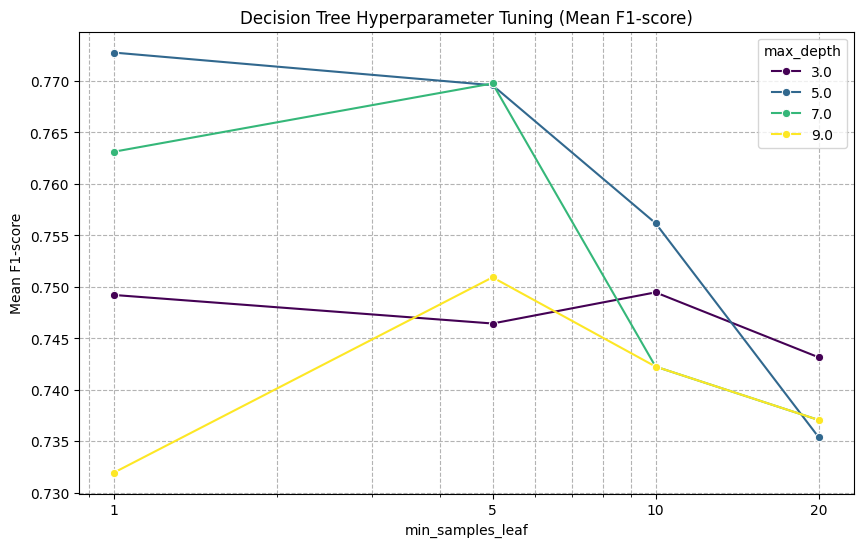

In [22]:
best_dt = DecisionTreeClassifier(
    random_state=13,
    max_depth=int(best_dt_row["max_depth"]),
    min_samples_leaf=int(best_dt_row["min_samples_leaf"])
)

f1_scores = []
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx, :], X.iloc[test_idx, :]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    best_dt.fit(X_train, y_train)
    y_pred = best_dt.predict(X_test)
    f1_scores.append(f1_score(y_test, y_pred))

print("Best Decision Tree – mean F1 over CV: {:.4f}".format(np.mean(f1_scores)))

# --- Plotting the results ---
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=dt_tuning_results,
    x="min_samples_leaf",
    y="mean_f1",
    hue="max_depth",
    marker="o",
    palette="viridis"
)
plt.title("Decision Tree Hyperparameter Tuning (Mean F1-score)")
plt.xlabel("min_samples_leaf")
plt.ylabel("Mean F1-score")
plt.xscale("log")
plt.xticks(param_grid_dt["min_samples_leaf"], labels=param_grid_dt["min_samples_leaf"])
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend(title="max_depth")
plt.show()

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_default = RandomForestClassifier(
    random_state=13,
    n_estimators=100,
    n_jobs=-1
)

rf_f1_scores = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx, :], X.iloc[test_idx, :]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf_default.fit(X_train, y_train)
    y_pred = rf_default.predict(X_test)
    rf_f1_scores.append(f1_score(y_test, y_pred))

print("Random Forest (default n_estimators=100) – mean F1: {:.4f}".format(np.mean(rf_f1_scores)))


Random Forest (default n_estimators=100) – mean F1: 0.7712


In [24]:
# 7) Experiment s n_estimators u Random Forest

n_estimators_list = [50, 100, 200, 400, 800]

rf_tuning_rows = []

for n_estimators in n_estimators_list:
    clf = RandomForestClassifier(
        random_state=13,
        n_estimators=n_estimators,
        n_jobs=-1
    )

    f1_scores = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx, :], X.iloc[test_idx, :]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        f1_scores.append(f1_score(y_test, y_pred))

    rf_tuning_rows.append({
        "n_estimators": n_estimators,
        "mean_f1": np.mean(f1_scores),
        "std_f1": np.std(f1_scores)
    })

rf_tuning_results = pd.DataFrame(rf_tuning_rows)
rf_tuning_results


,n_estimators,mean_f1,std_f1
0,50,0.779476,0.054906
1,100,0.771229,0.047552
2,200,0.771253,0.051316
3,400,0.775017,0.049293
4,800,0.768691,0.058583
